In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("E:/MASTER2(MASG)/DATA_SCIENCES_IA(Mr ONESIME)/PRATIQUE_data/Data_science_INOHA2026/INOHA-DataScience-M2/Student Exam.csv")
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [3]:
df.shape

(6607, 20)

In [10]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

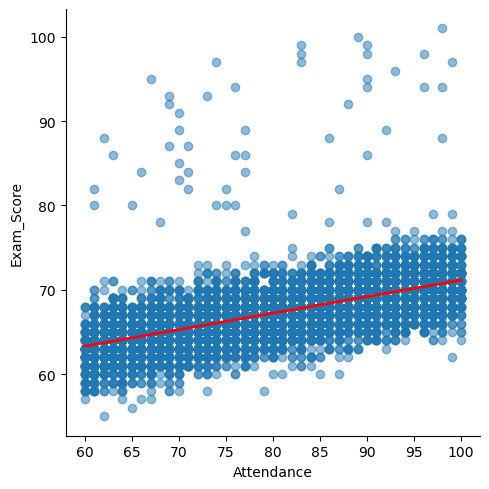

In [11]:
sns.lmplot(x='Attendance', y='Exam_Score', data =df,
           scatter_kws={'alpha':0.5},
           line_kws={'color':'red', 'linewidth':2})

In [12]:
from sklearn.model_selection import train_test_split

x=df['Attendance']
y=df['Exam_Score']

In [13]:
x_train,x_test,y_train,y_test= train_test_split(x, y, test_size=0.2, random_state=23)

In [14]:
x_train

2428     68
787      92
227      64
843      78
5036     74
       ... 
2998    100
1993     94
1064     94
4838     64
595      88
Name: Attendance, Length: 5285, dtype: int64

In [17]:
x_test

array([[98],
       [64],
       [90],
       ...,
       [65],
       [76],
       [82]], shape=(1322, 1))

In [15]:
x_train = np.array(x_train).reshape(-1,1)
x_test = np.array(x_test).reshape(-1,1)

In [16]:
from sklearn.linear_model import LinearRegression

model_RLS = LinearRegression()

model_RLS.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
B0 = model_RLS.intercept_
B0

np.float64(51.51530492986369)

In [ ]:
B1= model_RLS.coef_
B1

array([0.19655852])

In [18]:
y_pred = model_RLS.predict(x_test)
y_pred

array([70.77803975, 64.09505012, 69.20557161, ..., 64.29160864,
       66.45375235, 67.63310346], shape=(1322,))

In [19]:
y_test

3917    71
2842    69
806     71
6601    65
5787    71
        ..
4016    63
4798    67
4361    63
5235    67
1120    66
Name: Exam_Score, Length: 1322, dtype: int64

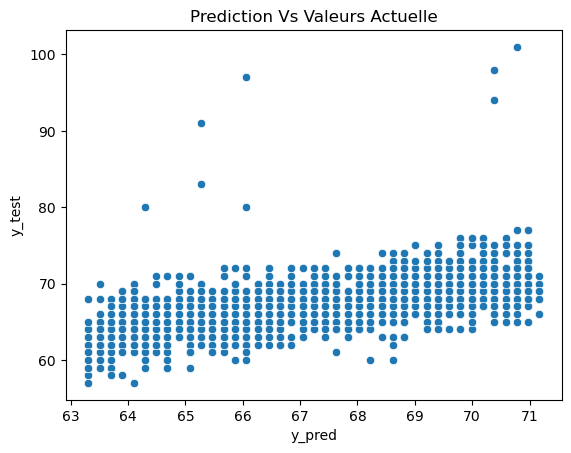

In [20]:
sns.scatterplot(x=y_pred.flatten(), y=y_test)
plt.xlabel('y_pred')
plt.ylabel('y_test')
plt.title('Prediction Vs Valeurs Actuelle')
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math


print("MSE",mean_squared_error(y_test, y_pred))
print("MAE",mean_absolute_error(y_test, y_pred))
print("RMSE",math.sqrt(mean_squared_error(y_test, y_pred)))
print("R2", r2_score(y_test, y_pred) )

MSE 9.624763705288181
MAE 2.0966903128562677
RMSE 3.1023803289229677
R2 0.34153713761934945


Mes Ajouts

In [ ]:
y_pred_series = pd.Series(y_pred.flatten(), index=y_test.index)
results_df = pd.DataFrame({'Exam Score': y_test, 'Valeur Predicte': y_pred_series})

results_df['Diff ou Risidual'] = np.abs(results_df['Exam Score'] - results_df['Valeur Predicte'])
display(results_df.head(15))

,Exam Score,Valeur Predicte,Diff ou Risidual
3917,71,70.778040,0.221960
2842,69,64.095050,4.904950
806,71,69.205572,1.794428
6601,65,67.829662,2.829662
5787,71,67.829662,3.170338
99,64,64.684726,0.684726
3064,69,70.974598,1.974598
1847,64,65.864077,1.864077
5698,62,63.505375,1.505375
761,68,67.239986,0.760014


### Erreur Absolue Moyenne (MAE - Mean Absolute Error)

**Formule :**

$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$

**Théorie et Interprétation :**
*   **Signification :** La MAE est la moyenne des valeurs absolues des erreurs. Elle mesure la magnitude moyenne des erreurs dans un ensemble de prédictions, sans considérer leur direction.
*   **Unité :** Elle est exprimée dans la même unité que la variable cible.
*   **Sensibilité :** Elle traite toutes les erreurs de manière égale. Elle est moins sensible aux valeurs aberrantes (outliers) que le MSE.
*   **Objectif :** Tendre vers 0.
*   **Interprétation :** Une MAE de 5 signifie qu'en moyenne, les prédictions s'écartent de 5 unités de la réalité. Un MAE plus proche de 0 indique un meilleur ajustement du modèle.



In [ ]:
# Calcul Manuel de MAE

y_test_np = y_test.to_numpy()  #ceci est notre y_test

y_pred_np = y_pred.flatten()  #Ceci est les Y Predicte

MAE = np.mean(np.abs(y_test_np - y_pred_np))

print(f"MAE Calculer est : {MAE}")

MAE Calculer est : 2.0966903128562677


### Erreur Quadratique Moyenne (MSE - Mean Squared Error)

**Formule :**

$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

**Théorie et Interprétation :**
*   **Signification :** Le MSE est la moyenne des carrés des erreurs. Il pénalise davantage les erreurs importantes que la MAE en raison de la mise au carré.
*   **Unité :** L'unité du MSE est le carré de l'unité de la variable cible (ex: euros², mètres², °C²), ce qui peut rendre son interprétation moins intuitive.
*   **Sensibilité :** Fortement sensible aux valeurs aberrantes, car les grandes erreurs sont amplifiées par la mise au carré.
*   **Objectif :** Tendre vers 0.
*   **Interprétation :** Un MSE plus proche de 0 indique un meilleur ajustement du modèle. C'est une métrique souvent utilisée pour optimiser les modèles, mais son échelle peut la rendre difficile à interpréter directement.



In [ ]:
# Calcul de MSE
MSE= np.mean((y_test_np - y_pred_np)**2)

print(f"MSE Calculer est: {MSE}")

MSE Calculer est: 9.624763705288181


### Racine Carrée de l'Erreur Quadratique Moyenne (RMSE / RSE - Root Mean Squared Error / Residual Standard Error)

**Formule :**

$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$

**Théorie et Interprétation :**
*   **Signification :** Le RMSE est la racine carrée du MSE. Il est souvent préféré au MSE car il ramène l'erreur à la même unité que la variable cible.
*   **Unité :** Comme la MAE, il est exprimé dans la même unité que la variable cible, ce qui facilite son interprétation.
*   **Sensibilité :** Également sensible aux valeurs aberrantes, car il dérive du MSE.
*   **Objectif :** Tendre vers 0.
*   **Interprétation :** Il représente l'écart type des résidus. Un RMSE de 3 signifie que les erreurs du modèle sont typiquement de l'ordre de 3 unités par rapport à la valeur réelle. Un RMSE plus proche de 0 indique un meilleur ajustement.



In [ ]:
import math
from sklearn.metrics import mean_squared_error

rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"RSE (RMSE): {rmse}")

RSE (RMSE): 3.1023803289229677


### Coefficient de Détermination (R² - R-squared)

**Formule :**

$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} = 1 - \frac{\text{MSE}}{\text{Variance de y}}$

**Théorie et Interprétation :**
*   **Signification :** Le R² mesure la proportion de la variance de la variable dépendante qui est expliquée par le modèle de régression. Il indique à quel point les prédictions sont proches des vraies valeurs.
*   **Unité :** C'est une valeur sans unité, généralement entre 0 et 1 (bien qu'elle puisse être négative pour des modèles très mauvais).
*   **Sensibilité :** Il est une mesure de la *qualité de l'ajustement* du modèle.
*   **Interprétation :**
    *   **R² proche de 1 :** Le modèle explique une grande partie de la variabilité de la variable cible. Par exemple, un R² de 0.8 signifie que 80% de la variance de la variable cible est expliquée par le modèle.
    *   **R² proche de 0 :** Le modèle explique très peu, voire aucune, de la variabilité de la variable cible. Le modèle n'est pas meilleur que la simple moyenne de la variable cible pour faire des prédictions.
    *   **R² négatif :** Le modèle est pire que de prédire la moyenne de la variable cible pour toutes les observations. Cela indique généralement un très mauvais ajustement du modèle ou une erreur dans le processus.

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2}")

R2 Score: 0.34153713761934945


Le score R2, également connu sous le nom de coefficient de détermination, est une mesure statistique qui représente la proportion de la variance de la variable dépendante (Exam_Score) qui peut être prédite à partir de la variable indépendante (Attendance).

Dans notre contexte actuel, un score R2 de 0,342 signifie qu'environ 34,2 % de la variation de l'Exam_Score peut être expliquée par l'Attendance. Les 65,8 % restants de la variance sont dus à d'autres facteurs non inclus dans notre modèle de régression linéaire simple ou à une variabilité aléatoire.

**Un peu plus en Deep**

* **Score R2 proche de 1 (ou 100 %)** : Indique que le modèle explique presque toute la variabilité de la variable dépendante autour de sa moyenne. Cela signifie que le modèle s'adapte très bien aux données.

*  **Score R2 proche de 0**: Indique que le modèle explique très peu de la variabilité de la variable dépendante. Cela suggère que le modèle est mal adapté aux données, ou que la variable indépendante ne prédit pas fortement la variable dépendante.

Dans notre cas, un **score R2 de 0,342** suggère que, bien que **l'Attendance** ait un certain pouvoir explicatif sur **l'Exam_Score**, il existe probablement d'autres facteurs significatifs influençant l'Exam_Score qui ne sont pas capturés par ce modèle simple.

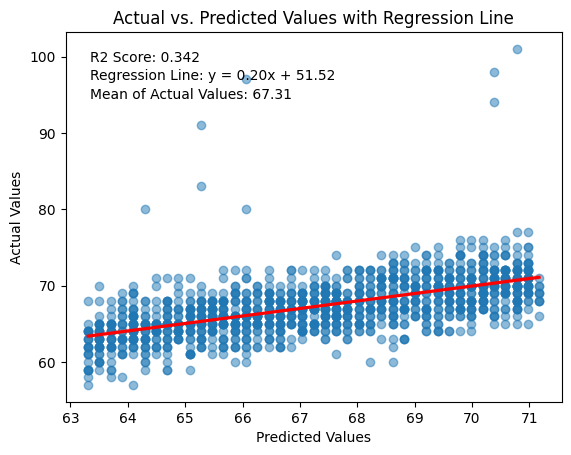

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.regplot(x=y_pred.flatten(), y=y_test, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Values with Regression Line')

plt.text(0.05, 0.95, f'R2 Score: {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')


plt.text(0.05, 0.90, f'Regression Line: y = {B1[0]:.2f}x + {B0:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

mean_y_test = y_test.mean()
plt.text(0.05, 0.85, f'Mean of Actual Values: {mean_y_test:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.show()

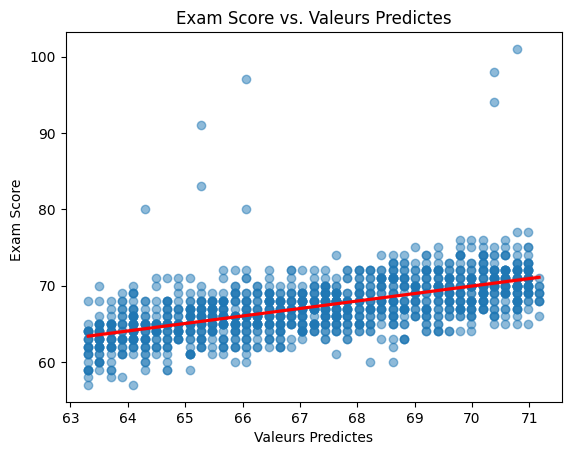

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.regplot(x=y_pred.flatten(), y=y_test, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Valeurs Predictes')
plt.ylabel('Exam Score ')
plt.title('Exam Score vs. Valeurs Predictes')
plt.show()

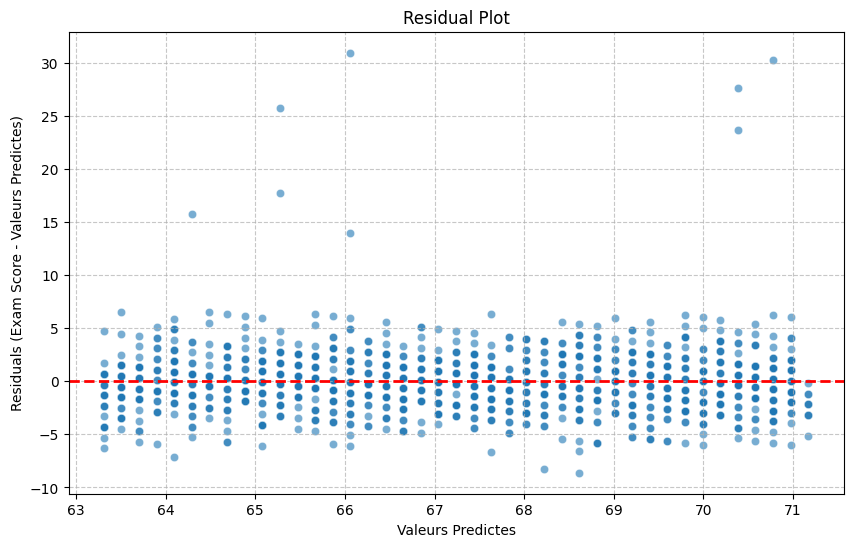

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# La Difference ou residuals
residuals = y_test - y_pred.flatten()

# Creation de Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred.flatten(), y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Valeurs Predictes')
plt.ylabel('Residuals (Exam Score - Valeurs Predictes)')
plt.title('Residual Plot')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
my_data = np.array([[78],[89],[98]])

prediction  = model_RLS.predict(my_data)
print(prediction)

[66.84686938 69.00901309 70.77803975]


## **1. Régression Linéaire Multiple**

**Quand l'utiliser ?** Lorsque vous avez plusieurs variables explicatives et que vous supposez que leur impact est additif.
- **Pourquoi ?** Très facile à interpréter. On sait exactement comment chaque variable influence le résultat.
- **Mathématiques** : On cherche à minimiser la Somme des Carrés des Résidus (RSS).$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon$$

In [5]:
dflm = pd.read_csv("E:/MASTER2(MASG)/DATA_SCIENCES_IA(Mr ONESIME)/PRATIQUE_data/Data_science_INOHA2026/INOHA-DataScience-M2/Student Exam.csv")
dflm

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [6]:
dflm.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [7]:
count = dflm.isnull().sum()
print(count)

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


Pourcentage de valeurs manquantes
-len permet de compter le nombres d'observations

In [22]:
missing_data = count/len(dflm)*100
print(missing_data)

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.222954
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.411101
Distance_from_Home            1.050486
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64


In [25]:
dflm = dflm.dropna() #dropna() permet de supprimer les valeurs manquantes
dflm.shape

(6378, 20)

In [24]:
dflm.info() # info() permet de voir le type de données

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6378 non-null   int64
 1   Attendance                  6378 non-null   int64
 2   Parental_Involvement        6378 non-null   int64
 3   Access_to_Resources         6378 non-null   int64
 4   Extracurricular_Activities  6378 non-null   int64
 5   Sleep_Hours                 6378 non-null   int64
 6   Previous_Scores             6378 non-null   int64
 7   Motivation_Level            6378 non-null   int64
 8   Internet_Access             6378 non-null   int64
 9   Tutoring_Sessions           6378 non-null   int64
 10  Family_Income               6378 non-null   int64
 11  Teacher_Quality             6378 non-null   int64
 12  School_Type                 6378 non-null   int64
 13  Peer_Influence              6378 non-null   int64
 14  Physical_Acti

In [11]:
dflm.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [26]:
df_txt = dflm.select_dtypes(include=["object"]) # .select_dtypes(include=["object"]) Permet de selectionner que les variables qui sont du type object
df_txt

""
0
1
2
3
4
...
6602
6603
6604
6605


In [13]:
df_txt.columns

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')

#  NOTA: TRANSFORMATION DE VARIABLES TEXTUELLES EN VARIABLES NUMERIQUES avec le package LabelEncoder

In [53]:
from sklearn.preprocessing import LabelEncoder   # LabelEncoder permet de rendre les variables textuelles en variables numériques

le = LabelEncoder()

columns = ['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender']                              # columns = [] est la liste  c

for i in columns :
  dflm[i] = le.fit_transform(dflm[i])    # .fit_transform(dflm[i]) : permet de transformer

In [54]:
dflm

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,0,2,0,7,76,2,1,1,0,2,1,2,2,0,1,2,0,68
6603,23,76,0,2,0,8,81,2,1,3,1,0,1,2,2,0,1,2,0,69
6604,20,90,2,1,1,6,65,1,1,3,1,2,1,0,2,0,2,2,0,68
6605,10,86,0,0,1,6,91,0,1,2,1,2,0,2,3,0,1,0,0,68


# NOTA: LA MISE A L'ECHELLE pour traiter les données abérantes en utilisant:
 - la normalisation  MinMaxScaler()
 - la standardisation 


In [44]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
dflm_min = minmax.fit_transform(dflm)

dflm_scaler = pd.DataFrame(dflm_min, columns =dflm.columns)

dflm_scaler

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,0.511628,0.600,0.5,0.0,0.0,0.500000,0.46,0.5,1.0,0.000,0.5,1.0,1.0,1.0,0.500000,0.0,0.5,1.0,1.0,0.260870
1,0.418605,0.100,0.5,1.0,0.0,0.666667,0.18,0.5,1.0,0.250,1.0,1.0,1.0,0.0,0.666667,0.0,0.0,0.5,0.0,0.130435
2,0.534884,0.950,1.0,1.0,1.0,0.500000,0.82,1.0,1.0,0.250,1.0,1.0,1.0,0.5,0.666667,0.0,1.0,1.0,1.0,0.413043
3,0.651163,0.725,0.5,1.0,1.0,0.666667,0.96,1.0,1.0,0.125,1.0,1.0,1.0,0.0,0.666667,0.0,0.5,0.5,1.0,0.347826
4,0.418605,0.800,1.0,1.0,1.0,0.333333,0.30,1.0,1.0,0.375,1.0,0.0,1.0,0.5,0.666667,0.0,0.0,1.0,0.0,0.326087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6373,0.558140,0.225,0.0,1.0,0.0,0.500000,0.52,1.0,1.0,0.125,0.0,1.0,1.0,1.0,0.333333,0.0,0.5,1.0,0.0,0.282609
6374,0.511628,0.400,0.0,1.0,0.0,0.666667,0.62,1.0,1.0,0.375,0.5,0.0,1.0,1.0,0.333333,0.0,0.5,1.0,0.0,0.304348
6375,0.441860,0.750,1.0,0.5,1.0,0.333333,0.30,0.5,1.0,0.375,0.5,1.0,1.0,0.0,0.333333,0.0,1.0,1.0,0.0,0.282609
6376,0.209302,0.650,0.0,0.0,1.0,0.333333,0.82,0.0,1.0,0.250,0.5,1.0,0.0,1.0,0.500000,0.0,0.5,0.0,0.0,0.282609


In [45]:
dflm_scaler.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [46]:
X = dflm_scaler.drop('Exam_Score', axis=1)  # .drop('Exam_Score', axis=1): pour affecter dans X toutes les variables de notre dataset en supprimant notre variable cible
y = dflm_scaler['Exam_Score']

In [47]:
X

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,0.511628,0.600,0.5,0.0,0.0,0.500000,0.46,0.5,1.0,0.000,0.5,1.0,1.0,1.0,0.500000,0.0,0.5,1.0,1.0
1,0.418605,0.100,0.5,1.0,0.0,0.666667,0.18,0.5,1.0,0.250,1.0,1.0,1.0,0.0,0.666667,0.0,0.0,0.5,0.0
2,0.534884,0.950,1.0,1.0,1.0,0.500000,0.82,1.0,1.0,0.250,1.0,1.0,1.0,0.5,0.666667,0.0,1.0,1.0,1.0
3,0.651163,0.725,0.5,1.0,1.0,0.666667,0.96,1.0,1.0,0.125,1.0,1.0,1.0,0.0,0.666667,0.0,0.5,0.5,1.0
4,0.418605,0.800,1.0,1.0,1.0,0.333333,0.30,1.0,1.0,0.375,1.0,0.0,1.0,0.5,0.666667,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6373,0.558140,0.225,0.0,1.0,0.0,0.500000,0.52,1.0,1.0,0.125,0.0,1.0,1.0,1.0,0.333333,0.0,0.5,1.0,0.0
6374,0.511628,0.400,0.0,1.0,0.0,0.666667,0.62,1.0,1.0,0.375,0.5,0.0,1.0,1.0,0.333333,0.0,0.5,1.0,0.0
6375,0.441860,0.750,1.0,0.5,1.0,0.333333,0.30,0.5,1.0,0.375,0.5,1.0,1.0,0.0,0.333333,0.0,1.0,1.0,0.0
6376,0.209302,0.650,0.0,0.0,1.0,0.333333,0.82,0.0,1.0,0.250,0.5,1.0,0.0,1.0,0.500000,0.0,0.5,0.0,0.0


In [48]:
y

0       0.260870
1       0.130435
2       0.413043
3       0.347826
4       0.326087
          ...   
6373    0.282609
6374    0.304348
6375    0.282609
6376    0.282609
6377    0.195652
Name: Exam_Score, Length: 6378, dtype: float64

In [55]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
from sklearn.linear_model import LinearRegression

model_LRM = LinearRegression()
model_LRM.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [57]:
bo = model_LRM.intercept_
bo

np.float64(-0.009142665827829799)

# les coefficients du modèle

In [59]:
coef = model_LRM.coef_
coef

array([ 2.73476187e-01,  1.71828929e-01, -1.77157873e-02, -1.75273662e-02,
        1.17594491e-02, -3.04080432e-03,  5.14491695e-02, -7.76643281e-03,
        1.97715990e-02,  8.37486597e-02, -7.04372262e-03, -1.12929121e-02,
        1.82266866e-04,  2.23914800e-02,  2.35614608e-02, -1.87370440e-02,
        7.37832630e-03,  2.08837259e-02, -4.46833268e-04])

# LE MODELE PREDICTIF  en utilisant la régression linéaire multiple

.predict(x_test) permet de faire la prédiction

In [60]:
y_pred = model_LRM.predict(x_test)
y_pred

array([0.39940536, 0.22803057, 0.33711185, ..., 0.22300448, 0.29231511,
       0.36961557], shape=(1276,))

In [63]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math

print("MSE",mean_squared_error(y_test, y_pred))
print("MAE",mean_absolute_error(y_test, y_pred))
print("RMSE",math.sqrt(mean_squared_error(y_test, y_pred)))
print("R2", r2_score(y_test, y_pred) )

MSE 0.0024646480999749977
MAE 0.023135083507869685
RMSE 0.04964522232778294
R2 0.6643872636734858


# **2. Autres Types de Régressions**

**2. Régression Polynomiale**

Si vos données ne suivent pas une ligne droite mais une courbe, on ajoute des puissances aux variables ($x^2, x^3$).



**Quand l'utiliser ?** Quand la courbe des données présente des courbures (non-linéarité).
**Pourquoi ?** Permet de capturer des relations complexes avec un cadre linéaire (en transformant les variables).
**Mathématiques** : On crée des puissances des variables existantes.$$y = \beta_0 + \beta_1x + \beta_2x^2 + ... + \beta_nx^n$$

In [ ]:
X

In [ ]:
y

0       0.260870
1       0.130435
2       0.413043
3       0.347826
4       0.326087
          ...   
6373    0.282609
6374    0.304348
6375    0.282609
6376    0.282609
6377    0.195652
Name: Exam_Score, Length: 6378, dtype: float64

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly_reg = PolynomialFeatures(degree = 4)
X_poly = poly_reg.fit_transform(X)


x_train, x_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
model_poly = lin_reg.fit(x_train, y_train)
#lin_reg.fit(X_poly, y)

In [ ]:
b0 = model_poly.intercept_
b0

np.float64(0.02582494562659149)

In [ ]:
coef = model_poly.coef_
coef

array([ 3.08008827e-14, -3.55215998e-02,  4.68478535e-02, ...,
        4.74953338e-02,  5.98695976e-02,  5.97876778e-02], shape=(8855,))

In [ ]:
y_pred = model_poly.predict(x_test)

In [ ]:
df = pd.DataFrame({'Real Values':y_test, 'Predicted Values':y_pred})
df

,Real Values,Predicted Values
2718,0.413043,0.002835
4275,0.239130,0.320500
4141,0.326087,0.441870
1199,0.369565,0.678169
4546,0.260870,0.487481
...,...,...
6011,0.304348,-0.060885
5294,0.217391,-0.009911
4905,0.173913,-0.393566
6278,0.260870,0.647519


In [ ]:
print("MSE",mean_squared_error(y_test, y_pred))
print("MAE",mean_absolute_error(y_test, y_pred))
print("RMSE",math.sqrt(mean_squared_error(y_test, y_pred)))
print("R2", r2_score(y_test, y_pred) )

NameError: name 'mean_squared_error' is not defined

**3. Régressions Régularisées (Ridge et Lasso)**

Ces modèles sont des variantes de la régression linéaire qui ajoutent une "pénalité" mathématique pour éviter que le modèle ne devienne trop complexe (surapprentissage).

**Ridge** : Utile quand vous avez beaucoup de variables corrélées entre elles.

**Lasso** : Très puissant pour la sélection de variables, car il peut annuler l'influence des variables inutiles.

**Quand les utiliser ?** Quand vous avez beaucoup de variables (risque de Overfitting) ou des variables très corrélées.
- **Ridge (L2)**: Écrase les coefficients vers 0 sans jamais les annuler. Utile pour la stabilité.
- **Lasso (L1)** : Peut annuler certains coefficients ($= 0$). Utile pour **la sélection de variables**.

- **Mathématiques** : On ajoute une pénalité à la fonction de coût.

    - Ridge : $RSS + \lambda \sum \beta_j^2$
    - Lasso : $RSS + \lambda \sum |\beta_j|$

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# --- RÉGRESSION RIDGE (L2) ---
# alpha est le paramètre de régularisation (lambda)
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)


Ridge()

In [ ]:
b0 = ridge.intercept_
b0

np.float64(0.26654128235317487)

In [ ]:
coef =  ridge.coef_
coef

array([ 3.80564764e-02,  4.96049187e-02, -7.66118360e-03, -7.63061328e-03,
        5.76690449e-03, -7.43966054e-04,  1.48135675e-02, -3.04022484e-03,
        5.23959787e-03,  1.29145028e-02, -2.61433244e-03, -5.07426691e-03,
        8.36688828e-05,  8.46610207e-03,  4.03904873e-03, -5.73664306e-03,
        2.59270436e-03,  6.99883417e-03, -2.20564864e-04])

In [ ]:
y_pred_ridge = ridge.predict(x_test)

In [ ]:
df = pd.DataFrame({'Real Values':y_test, 'Predicted Values':y_pred})
df

,Real Values,Predicted Values
2718,0.413043,0.268478
4275,0.239130,0.221822
4141,0.326087,0.295625
1199,0.369565,0.435702
4546,0.260870,0.241579
...,...,...
6011,0.304348,0.379471
5294,0.217391,0.165483
4905,0.173913,0.140673
6278,0.260870,0.332924


In [ ]:
# --- RÉGRESSION LASSO (L1) ---
# alpha élevé peut annuler certains coefficients
lasso = Lasso(alpha=0.1)
lasso.fit(x_train, y_train)


Lasso(alpha=0.1)

In [ ]:
b0 = ridge.intercept_
b0

np.float64(0.26654128235317487)

In [ ]:
coef =  ridge.coef_
coef

array([ 3.80564764e-02,  4.96049187e-02, -7.66118360e-03, -7.63061328e-03,
        5.76690449e-03, -7.43966054e-04,  1.48135675e-02, -3.04022484e-03,
        5.23959787e-03,  1.29145028e-02, -2.61433244e-03, -5.07426691e-03,
        8.36688828e-05,  8.46610207e-03,  4.03904873e-03, -5.73664306e-03,
        2.59270436e-03,  6.99883417e-03, -2.20564864e-04])

In [ ]:
y_pred_lasso = lasso.predict(x_test)

In [ ]:
df = pd.DataFrame({'Real Values':y_test, 'Predicted Values':y_pred})
df

,Real Values,Predicted Values
2718,0.413043,0.268478
4275,0.239130,0.221822
4141,0.326087,0.295625
1199,0.369565,0.435702
4546,0.260870,0.241579
...,...,...
6011,0.304348,0.379471
5294,0.217391,0.165483
4905,0.173913,0.140673
6278,0.260870,0.332924


**4. Régression par Arbres de Décision et Random Forest**

Au lieu d'utiliser une équation, ces modèles découpent l'espace de données en "blocs".

**Random Forest Regression** : Combine des centaines d'arbres pour obtenir une prédiction très stable.

**Avantage** : Capable de capturer des relations très complexes et non-linéaires sans transformation préalable des données.


**Quand les utiliser ?** Pour des données tabulaires avec des relations non-linéaires complexes ou des interactions entre variables.

**Pourquoi ?** Ne nécessite pas de normalisation des données et gère bien les valeurs manquantes.

**Mathématiques :** Découpage de l'espace en hyper-rectangles. La prédiction est la moyenne des valeurs cibles dans une "feuille".

In [ ]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor()
regressor.fit(x_train, y_train)

DecisionTreeRegressor()

In [ ]:
y_pred = regressor.predict(x_test)
y_pred

array([0.39116841, 0.24268411, 0.40144289, ..., 0.22761089, 0.37607489,
       0.34430118])

In [ ]:
df = pd.DataFrame({'Real Values':y_test, 'Predicted Values':y_pred})
df

,Real Values,Predicted Values
2718,0.413043,0.478261
4275,0.239130,0.260870
4141,0.326087,0.347826
1199,0.369565,0.369565
4546,0.260870,0.260870
...,...,...
6011,0.304348,0.282609
5294,0.217391,0.217391
4905,0.173913,0.260870
6278,0.260870,0.260870


In [ ]:
print("MSE",mean_squared_error(y_test, y_pred))
print("MAE",mean_absolute_error(y_test, y_pred))
print("RMSE",math.sqrt(mean_squared_error(y_test, y_pred)))
print("R2", r2_score(y_test, y_pred))

MSE 0.006206259518462112
MAE 0.036816818863295624
RMSE 0.07877981669477349
R2 0.15488960092733972


# Random Forest

In [ ]:
# Fitting Random Forest Regression to the dataset
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
regressor.fit(x_train, y_train)

RandomForestRegressor(n_estimators=10, random_state=0)

In [ ]:
y_pred = regressor.predict(x_test)
y_pred

array([0.43695652, 0.32608696, 0.3326087 , ..., 0.2       , 0.28478261,
       0.39347826])

In [ ]:
df = pd.DataFrame({'Real Values':y_test, 'Predicted Values':y_pred})
df

,Real Values,Predicted Values
2718,0.413043,0.436957
4275,0.239130,0.326087
4141,0.326087,0.332609
1199,0.369565,0.328261
4546,0.260870,0.271739
...,...,...
6011,0.304348,0.280435
5294,0.217391,0.197826
4905,0.173913,0.200000
6278,0.260870,0.284783


In [ ]:
print("MSE",mean_squared_error(y_test, y_pred))
print("MAE",mean_absolute_error(y_test, y_pred))
print("RMSE",math.sqrt(mean_squared_error(y_test, y_pred)))
print("R2", r2_score(y_test, y_pred))

MSE 0.0030347523866525233
MAE 0.02689791467902412
RMSE 0.05508858671859829
R2 0.5867557918032171


**5. Support Vector Regression (SVR)**

Contrairement à la régression linéaire qui cherche à minimiser l'erreur totale, la SVR cherche à faire passer le maximum de points dans un "tube" autour de la ligne de prédiction.

**Usage** : Très efficace pour les petits jeux de données avec des relations non-linéaires (en utilisant des noyaux/kernels).


**Quand l'utiliser ?** Pour des jeux de données de taille moyenne où la précision est prioritaire sur l'interprétabilité.

**Pourquoi ?** Robuste aux valeurs aberrantes (outliers).

**Mathématiques** : Contrairement aux moindres carrés, on cherche à inclure le plus de points possible dans une zone de tolérance $\epsilon$ autour de la droite.

In [ ]:
X

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,0.511628,0.600,0.5,0.0,0.0,0.500000,0.46,0.5,1.0,0.000,0.5,1.0,1.0,1.0,0.500000,0.0,0.5,1.0,1.0
1,0.418605,0.100,0.5,1.0,0.0,0.666667,0.18,0.5,1.0,0.250,1.0,1.0,1.0,0.0,0.666667,0.0,0.0,0.5,0.0
2,0.534884,0.950,1.0,1.0,1.0,0.500000,0.82,1.0,1.0,0.250,1.0,1.0,1.0,0.5,0.666667,0.0,1.0,1.0,1.0
3,0.651163,0.725,0.5,1.0,1.0,0.666667,0.96,1.0,1.0,0.125,1.0,1.0,1.0,0.0,0.666667,0.0,0.5,0.5,1.0
4,0.418605,0.800,1.0,1.0,1.0,0.333333,0.30,1.0,1.0,0.375,1.0,0.0,1.0,0.5,0.666667,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6373,0.558140,0.225,0.0,1.0,0.0,0.500000,0.52,1.0,1.0,0.125,0.0,1.0,1.0,1.0,0.333333,0.0,0.5,1.0,0.0
6374,0.511628,0.400,0.0,1.0,0.0,0.666667,0.62,1.0,1.0,0.375,0.5,0.0,1.0,1.0,0.333333,0.0,0.5,1.0,0.0
6375,0.441860,0.750,1.0,0.5,1.0,0.333333,0.30,0.5,1.0,0.375,0.5,1.0,1.0,0.0,0.333333,0.0,1.0,1.0,0.0
6376,0.209302,0.650,0.0,0.0,1.0,0.333333,0.82,0.0,1.0,0.250,0.5,1.0,0.0,1.0,0.500000,0.0,0.5,0.0,0.0


In [ ]:
y

,Exam_Score
0,0.260870
1,0.130435
2,0.413043
3,0.347826
4,0.326087
...,...
6373,0.282609
6374,0.304348
6375,0.282609
6376,0.282609


In [ ]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
#y = sc_y.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [ ]:
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(X_train, y_train)

SVR()

In [ ]:
y_pred = regressor.predict(X_test)
#y_pred = sc_y.inverse_transform(y_pred)
y_pred

array([0.26847802, 0.22182184, 0.29562525, ..., 0.14067308, 0.3329243 ,
       0.17066476])

In [ ]:
df = pd.DataFrame({'Real Values':y_test, 'Predicted Values':y_pred})
df

,Real Values,Predicted Values
2991,0.282609,0.268478
751,0.239130,0.221822
3549,0.347826,0.295625
2944,0.369565,0.435702
1444,0.173913,0.241579
...,...,...
1155,0.326087,0.379471
763,0.195652,0.165483
5683,0.130435,0.140673
4959,0.369565,0.332924


In [ ]:
print("MSE",mean_squared_error(y_test, y_pred))
print("MAE",mean_absolute_error(y_test, y_pred))
print("RMSE",math.sqrt(mean_squared_error(y_test, y_pred)))
print("R2", r2_score(y_test, y_pred))

MSE 0.005047858673645953
MAE 0.048193340820055004
RMSE 0.07104828410064491
R2 0.29986928710613403


# **Comparaison Multi-Modèles**

Dans le code suivant, nous avons cherché à optimiser chaque modèle, tout en mettant en place un pipeline permettant de comparer plusieurs modèles de régression et d’évaluer leurs performances à l’aide des métriques étudiées lors des séances précédentes. Nous reviendrons sur ce travail lors de la prochaine séance afin d’expliquer en détail le code ainsi que le fonctionnement des différents algorithmes de régression.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def comparer_regressions():
    # 1. Chargement des données
    X = dflm_scaler.drop('Exam_Score', axis=1)
    y = dflm_scaler['Exam_Score']


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Les Modèles
    modeles = {
        "Linéaire Multiple": Pipeline([('scaler', StandardScaler()), ('reg', LinearRegression())]),
        "Ridge (L2)": Pipeline([('scaler', StandardScaler()), ('reg', Ridge(alpha=1.0))]),
        "Lasso (L1)": Pipeline([('scaler', StandardScaler()), ('reg', Lasso(alpha=0.1))]),
        "Polynomiale (Deg 2)": Pipeline([('scaler', StandardScaler()), ('poly', PolynomialFeatures(degree=2)), ('reg', LinearRegression())]),

        # Modèle basé sur la marge (SVM)
        "Support Vector Regression (SVR)": Pipeline([('scaler', StandardScaler()), ('reg', SVR(kernel='rbf', C=1.0, epsilon=0.1))]),

        # Modèles basés sur les arbres
        "Arbre de Décision": DecisionTreeRegressor(random_state=42), # Arbre simple, souvent sujet à l'overfitting
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),

        # Modèles de Boosting
        "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
        "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
    }

    resultats = []

    # 3. Entraînement et Évaluation
    for nom, modele in modeles.items():

        modele.fit(X_train, y_train) # Entraînement


        y_pred = modele.predict(X_test)   # Prédiction

        # Calcul des métriques
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        resultats.append({
            "Modèle": nom,
            "RMSE": round(rmse, 4),
            "MAE": round(mae, 4),
            "R² Score": round(r2, 4)
            #"MSE": round(mean_squared_error(y_test, y_pred), 4)
        })

    # 4. Création du tableau récapitulatif
    df_perf = pd.DataFrame(resultats).sort_values(by="R² Score", ascending=False)
    return df_perf


tableau_performance = comparer_regressions()
print(tableau_performance.to_markdown(index=False))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000425 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 189
[LightGBM] [Info] Number of data points in the train set: 5102, number of used features: 19
[LightGBM] [Info] Start training from score 0.266247
| Modèle                          |   RMSE |    MAE |   R² Score |
|:--------------------------------|-------:|-------:|-----------:|
| Polynomiale (Deg 2)             | 0.0457 | 0.0133 |     0.7159 |
| LightGBM                        | 0.0478 | 0.0186 |     0.6894 |
| XGBoost                         | 0.0488 | 0.0191 |     0.6757 |
| Linéaire Multiple               | 0.0496 | 0.0231 |     0.6644 |
| Ridge (L2)                      | 0.0496 | 0.0231 |     0.6644 |
| Random Forest                   | 0.0531 | 0.026  |     0.6166 |
| Support Vector Regression (SVR) | 0.0719 | 0.0479 |     0.